<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- 지난 시간에 이어서 데이터 읽고 간단한 시각화

In [ ]:
import pandas as pd


df = pd.read_csv('/content/auto.csv')

In [ ]:
# df.head()
# !pip install koreanize-matplotlib

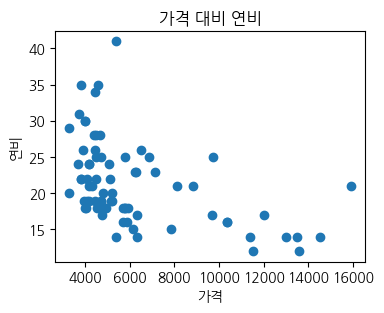

In [ ]:
# 시각화: 산포도
# 가격 price 와 연비 mpg 간의 산포도
# 상관관계
# matplotlib

import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.figure(figsize=(4,3))
plt.scatter(df['price'], df['mpg'])
plt.xlabel('가격')
plt.ylabel('연비')
plt.title('가격 대비 연비')
plt.show()

## 확률변수(random variable)와 분포(distribution)

- 확률변수 $X$
  - 이산확률변수: $X$가 가질 수 있는 값의 갯수가 유한개(셀 수 있으면)
  - 연속확률변수: $X$가 가질 수 있는 값의 갯수가 무한개(셀 수 없으면)

- 확률변수 $X$의 특성 중 하나인 분포(distribution)에 관심
  - 누적분포함수(cumulative distribution function, CDF)

$$
F_X (x) = \Pr (X \leq x)
$$

  - $X$가 이산이면 확률질량함수(probability mass function, pmf)을
  - $X$가 연속이면 확률밀도함수(probability density function, pdf)을 사용한다.


### 대표적인 이산확률분포: 베르누이 분포(Bernoulli distribution)

- 베르누이 시행: 동전 던지기.
- dummy variable: 관심 있는 사건이 일어나면 1, 아니면 0

- $f(X=1) = \Pr( \{Head\} ) = p$ , $f(X=0) = \Pr( \{Tail\} ) = 1-p$

 - 베르누이 분포의 중요한 모수는 $p$

In [ ]:
# 베르누이 시행

import numpy as np

np.random.seed(0)

n = 20
u = np.random.uniform(0,1, n)
# print(u)
x = np.where(u > 0.3, 1, 0)
print("코로나 걸렸었는지 안걸렸었는지", x)

코로나 걸렸었는지 안걸렸었는지 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1]


### 갯수를 세는 확률변수

- $B_i \sim Ber(p)$ 를 따르는 베르누이 시행
- 그러면 $B_i$ 의 합 $X$은 1인 사건의 갯수를 세게 됨

$$
X = \sum_{i=1}^n B_i
$$

- $X$는 이항분포(binomial distribution)를 따른다고 하고
$$
X \sim B(n, p)
$$

- $E[X] = n p$ 이고, $var(X) = n p (1-p) $

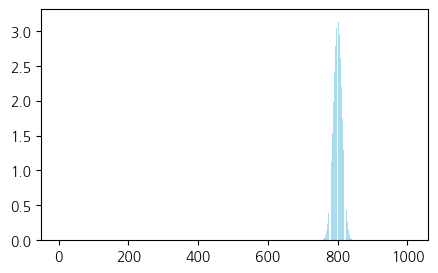

In [ ]:
# 이항분포: 갯수를 세는 확률변수를 모형
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import koreanize_matplotlib

# 시뮬레이션에 필요한 파라미터 정의
n = 1000
p = 0.8
x = np.arange(0, n*(1+0.01))

prob = binom.pmf(x, n, p)*100

plt.figure(figsize=(5,3))
plt.bar(x, prob, alpha=0.7, color='skyblue')
plt.show()

### 연속확률변수 중 대표적인 분포 정규분포

- $X \sim N(\mu, \sigma^2)  $, 평균이 $\mu$, 분산이 $\sigma^2$

- $X \sim N(0,1^2) $ 표준정규분포(standard normal distribution)

- 표준정규분포의 pdf(probability density function), gaussian

$$
f(x) = \frac{1}{ \sqrt{2 \pi}  } \exp( - \frac{x^2}{2} )
$$





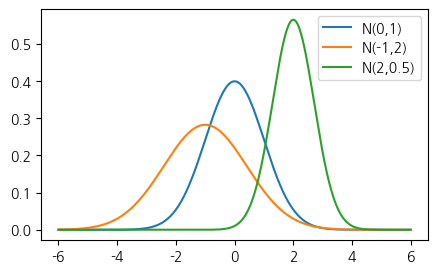

In [ ]:
# 평균 0, 표준편차 1인 표준정규분포의
# 확률밀도함수를 그릴 것임

# scipy.stats 을 사용

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import koreanize_matplotlib

x = np.arange(-6, 6, 0.001)
# print(x)

# 평균 0에, 분산 1(표준편차 = 1)
y1 = norm.pdf(x, loc=0, scale=1)

# 평균 -1이고, 분산이 2인 정규분포
y2 = norm.pdf(x, loc=-1, scale=np.sqrt(2))

# 평균 2이고 분산은 0.5인 정규분포를 추가하시오
y3 = norm.pdf(x, loc=2, scale=np.sqrt(0.5))

plt.figure(figsize=(5,3))
plt.plot(x, y1, label='N(0,1)')
plt.plot(x, y2, label='N(-1,2)')
plt.plot(x, y3, label='N(2,0.5)')
plt.legend()
plt.show()